# **Machine learning Assignment - 252**
**Group member:**
- Phan Van Minh Tien - 2153888
- Le Quang Thanh - 2252749
- To Dang Duc Tai - 2252725
- Nguyen Trong Minh Anh - 2252483
- Nguyen Thi Anh Thuy - 2252792

**Instructor:** Dr. Truong Vinh Lan


### **Step 1: EDA (Exploratory Data Analysis)**
Include:
1. Descriptive statistics
2. Data visualization
3. Detect missing values
4. Outliers and distribution trends

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os
import numpy as np
import os

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score, accuracy_score

# Configure inline plotting for VS Code/Jupyter
%matplotlib inline
sns.set(style="whitegrid")

dataset_url = 'https://raw.githubusercontent.com/PhanVanMinhTien/ml-project/main/datasets/healthcare-dataset-stroke-data.csv'

# 2. Data Loading Logic
print(f"Downloading dataset from: {dataset_url}")
try:
    df = pd.read_csv(dataset_url)
    print("Success: Dataset loaded successfully from public URL")
except Exception as e:
    print(f"Error:{e}")

# 3. Initial Inspection
if 'df' in locals():
    print(f"Dataset Shape: {df.shape}")
    display(df.head())

Success: Dataset loaded successfully from public URL
Dataset Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
# ============================================================
# Cell 2: Descriptive Statistics
# ============================================================
print("--- Basic Information ---")
print(df.info())

print("\n--- Numerical Summary ---")
# Provides mean, std, min, max, and quartiles
display(df[['age', 'avg_glucose_level', 'bmi']].describe())

print("\n--- Categorical Summary ---")
# Provides unique counts and most frequent values
display(df.describe(include=['object']))

--- Basic Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

--- Numerical Summary ---


,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000



--- Categorical Summary ---


,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


--- Missing Value Count ---
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


<Figure size 1000x400 with 0 Axes>

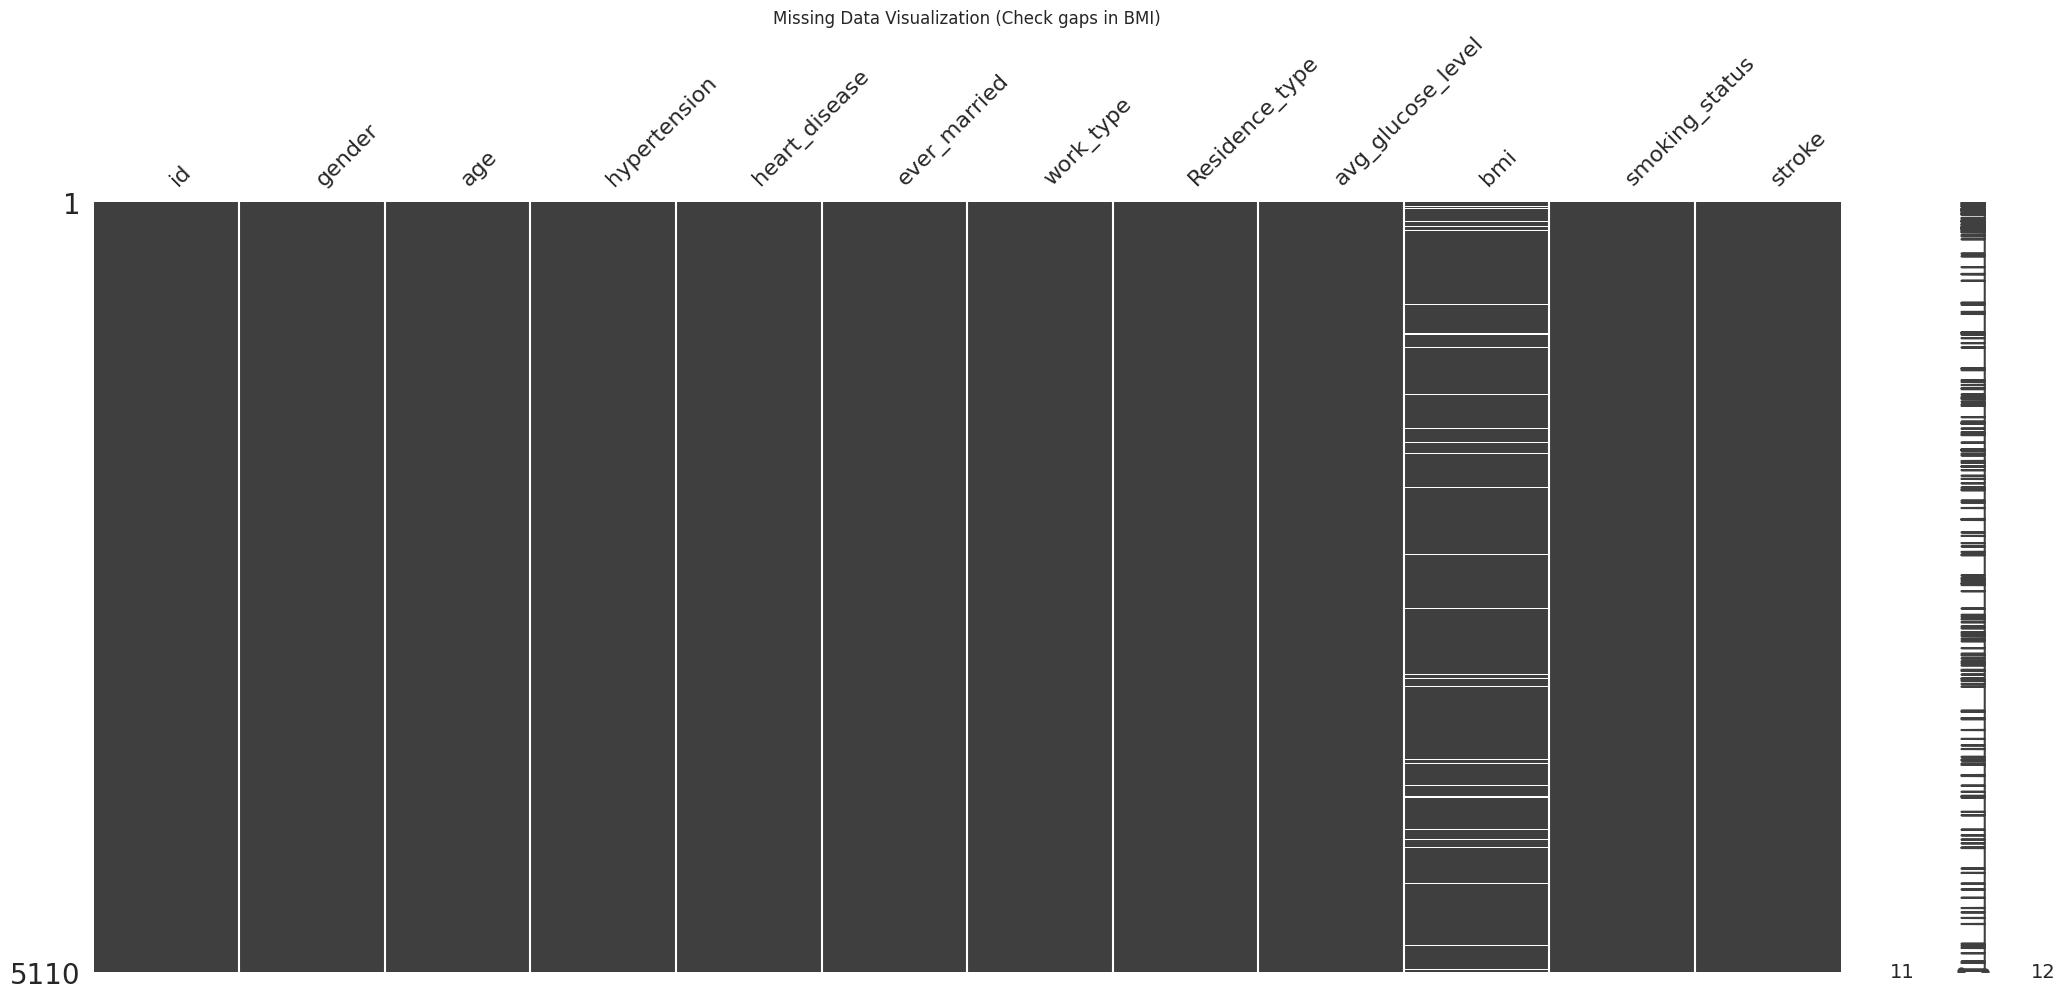

In [ ]:
# ============================================================
# Cell 3: Missing Value Analysis
# ============================================================
print("--- Missing Value Count ---")
print(df.isnull().sum())

# Visualizing missing values using missingno matrix
plt.figure(figsize=(10, 4))
msno.matrix(df)
plt.title("Missing Data Visualization (Check gaps in BMI)")
plt.show()

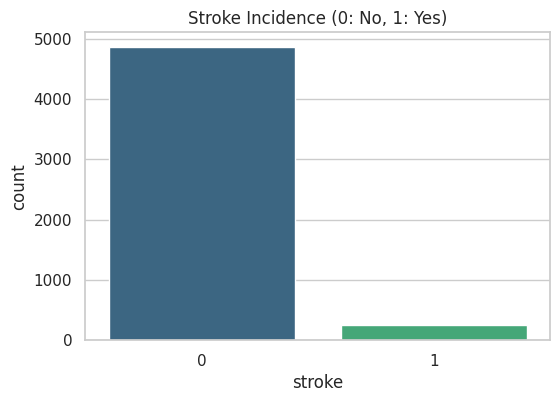

Stroke Incidence Rate: 4.87%
Note: This indicates a significant class imbalance.


In [ ]:
# ============================================================
# Cell 4: Target Variable Distribution (Stroke)
# ============================================================
plt.figure(figsize=(6, 4))
# Fixed: Assigned 'x' to 'hue' and set legend=False to avoid FutureWarnings
sns.countplot(x='stroke', data=df, hue='stroke', palette='viridis', legend=False)
plt.title('Stroke Incidence (0: No, 1: Yes)')
plt.show()

# Calculate the imbalance percentage
stroke_pct = df['stroke'].value_counts(normalize=True) * 100
print(f"Stroke Incidence Rate: {stroke_pct[1]:.2f}%")
print("Note: This indicates a significant class imbalance.")

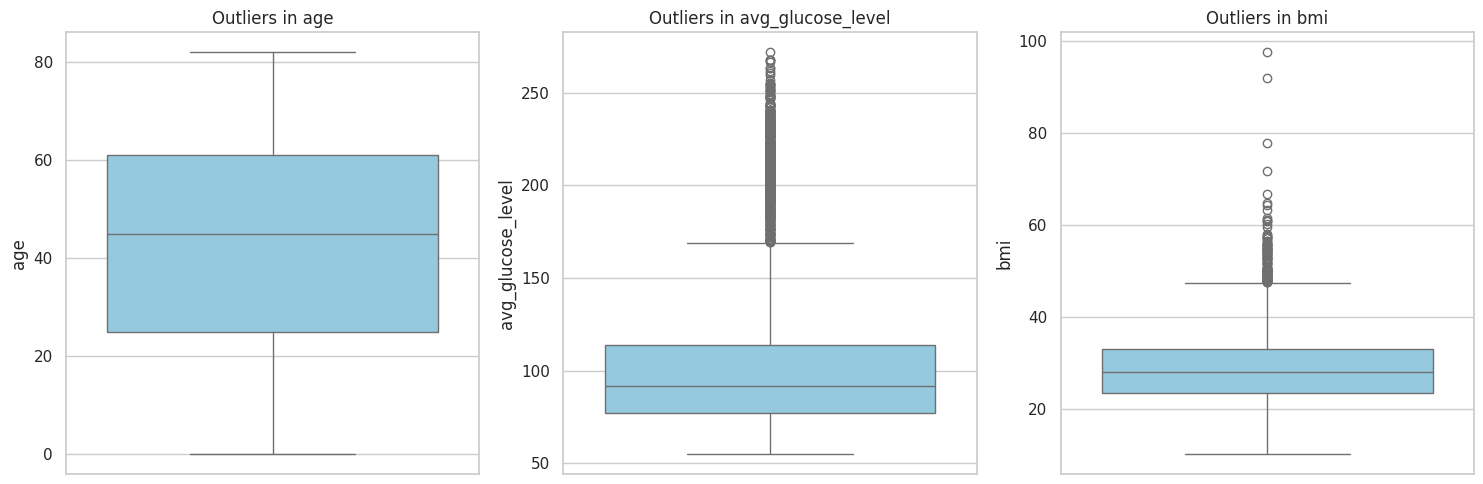

In [ ]:
# ============================================================
# Cell 5: Outlier Detection (Boxplots)
# ============================================================
numerical_cols = ['age', 'avg_glucose_level', 'bmi']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

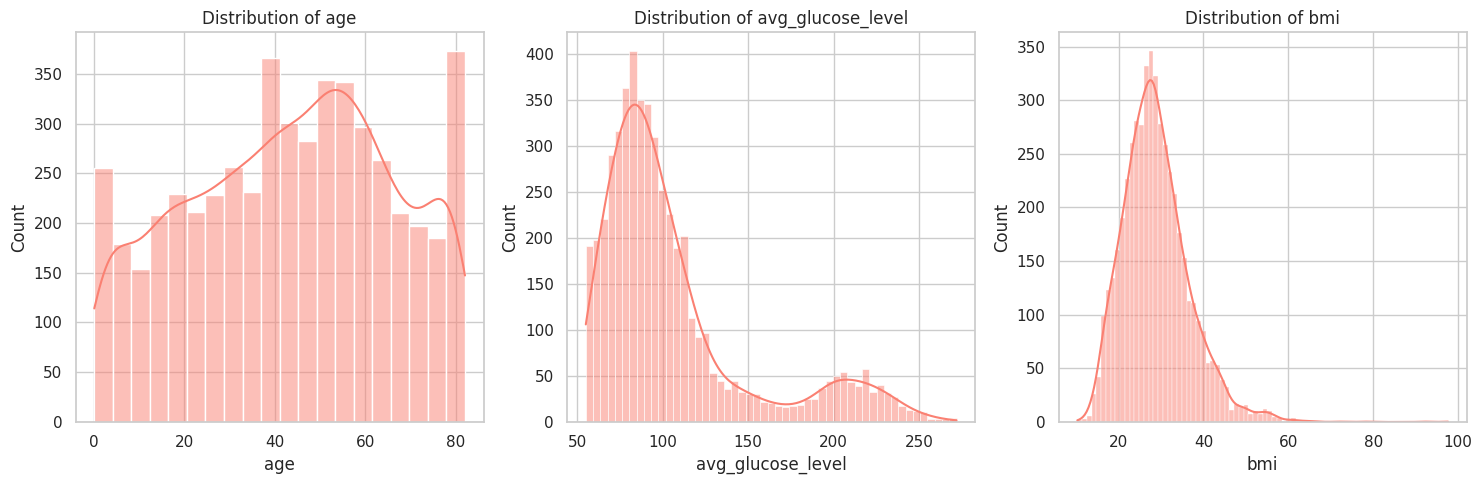

In [ ]:
# ============================================================
# Cell 6: Distribution Trends (Histograms)
# ============================================================
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='salmon')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

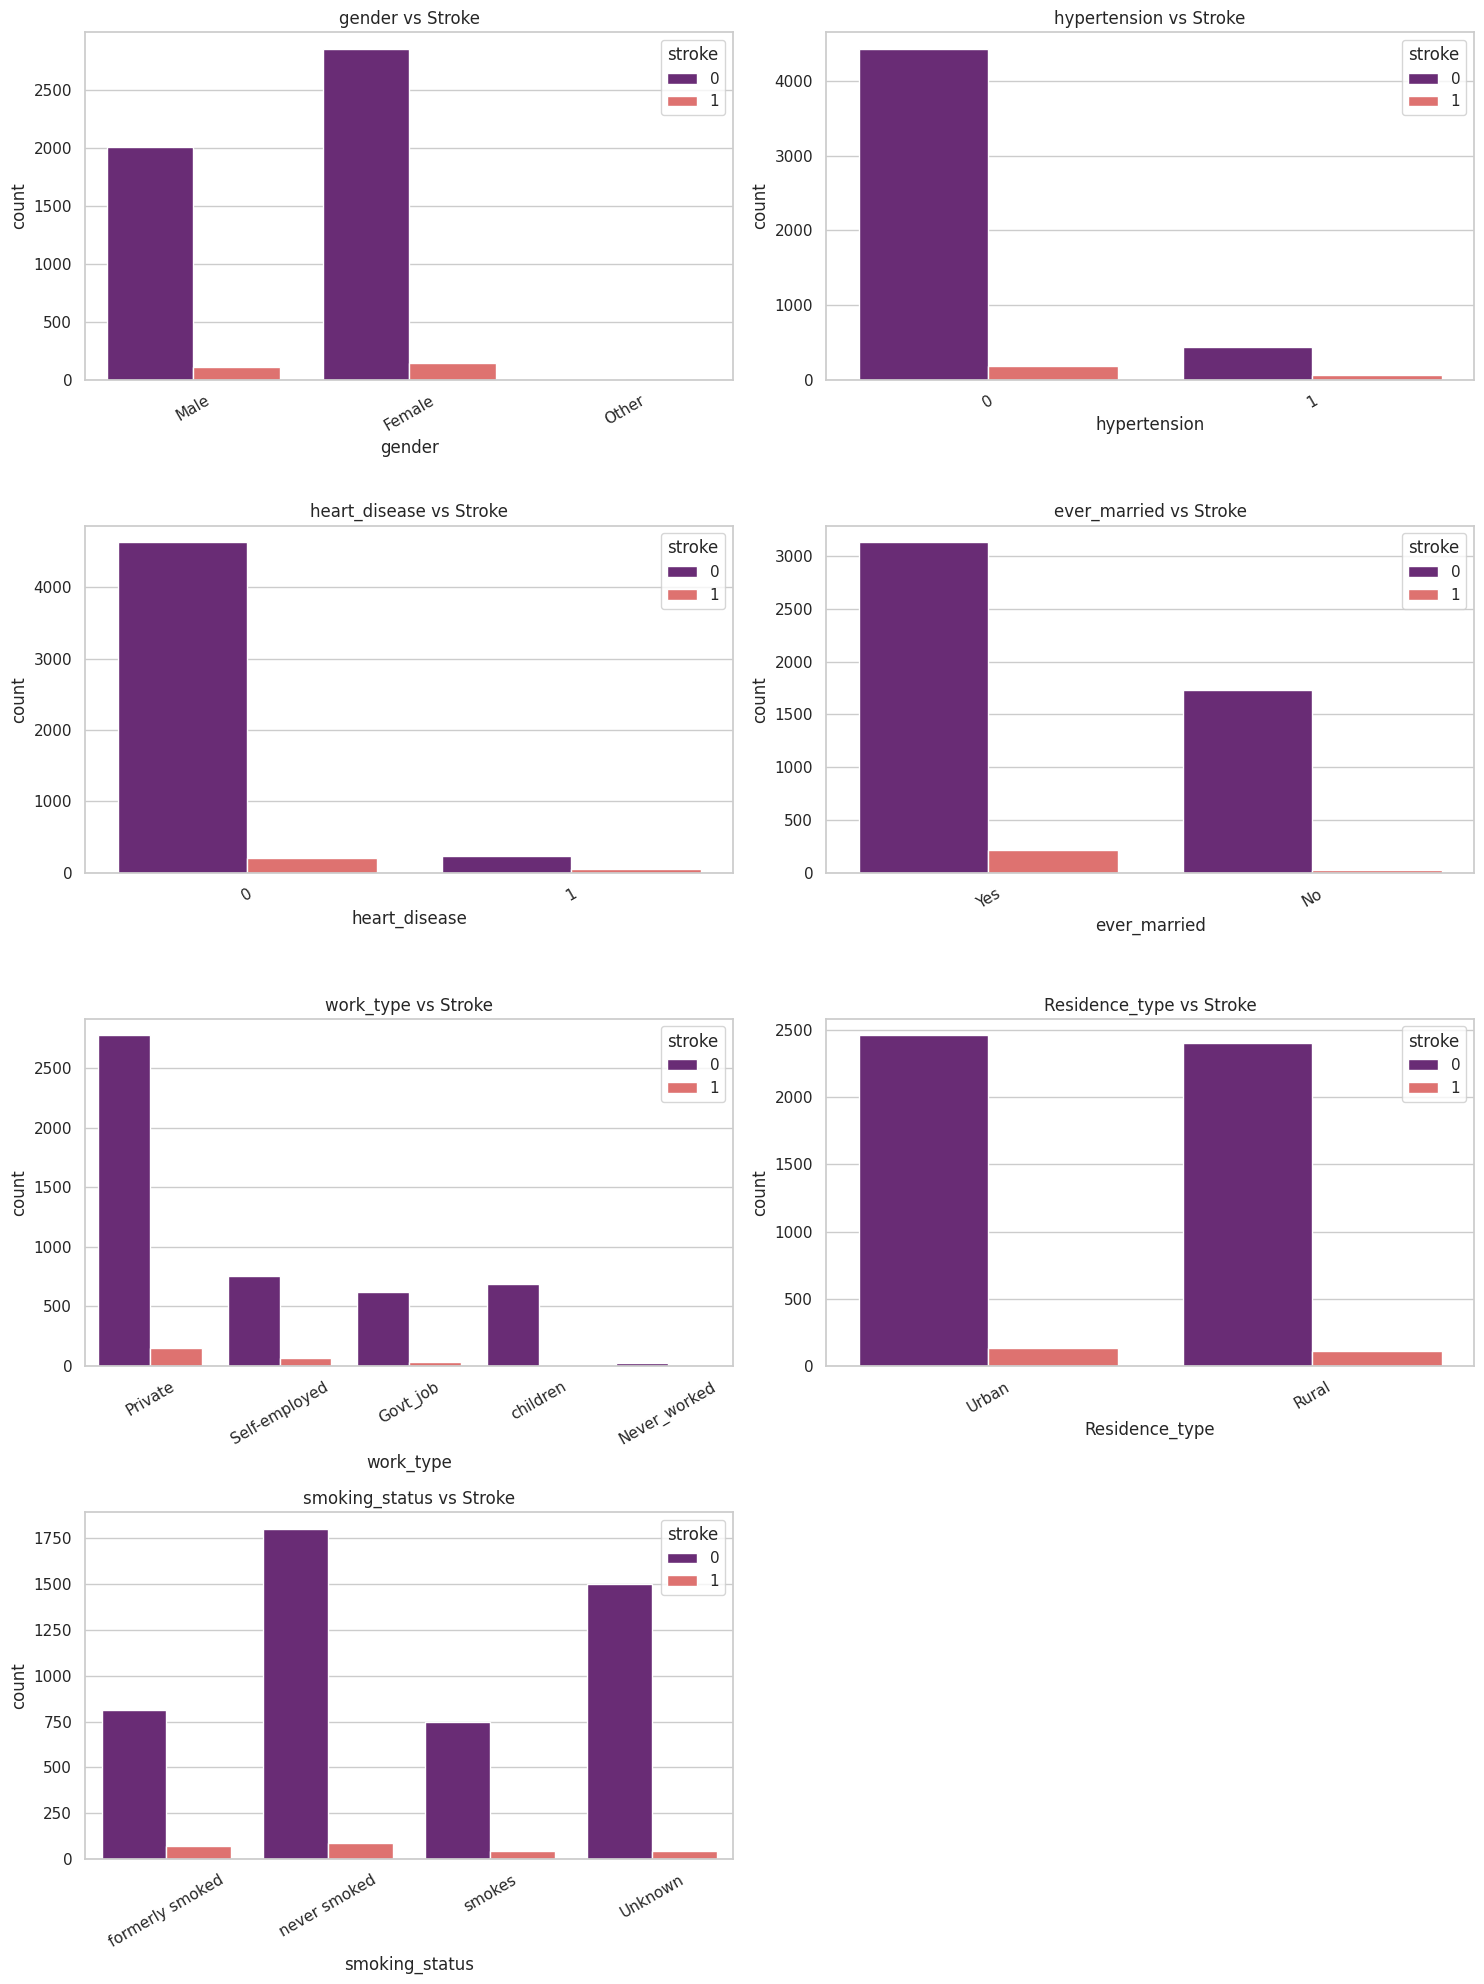

In [ ]:
# ============================================================
# Cell 7: Categorical Features relative to Stroke
# ============================================================
cat_features = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(x=col, hue='stroke', data=df, ax=axes[i], palette='magma')
    axes[i].set_title(f'{col} vs Stroke')
    axes[i].tick_params(axis='x', rotation=30)

# Delete the empty 8th subplot
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

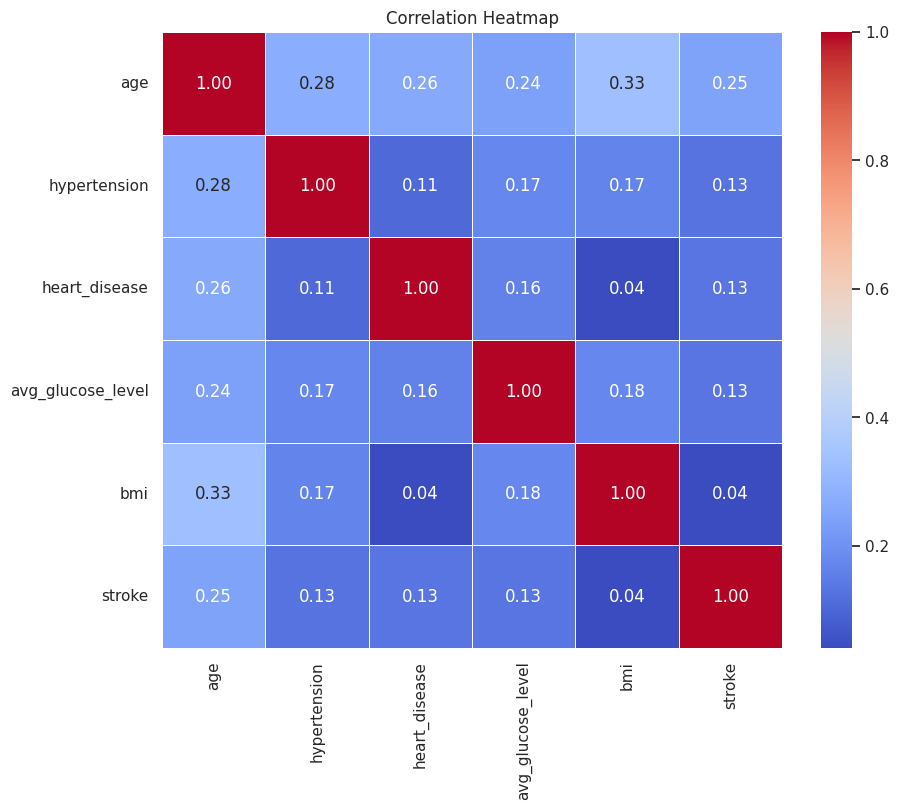

In [ ]:
# ============================================================
# Cell 8: Numeric Feature Correlation Matrix
# ============================================================
plt.figure(figsize=(10, 8))

# Drop 'id' as it is a unique identifier with no predictive value
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['id'])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### **Step 2: Data preprocess**

In [ ]:
# 1. Xử lý giá trị thiếu cho cột 'bmi' (201 giá trị thiếu)
imputer = SimpleImputer(strategy='median')
df['bmi'] = imputer.fit_transform(df[['bmi']])

# 2. Mã hóa các biến phân loại (Categorical values)
# Yêu cầu bắt buộc để thực hành kỹ thuật encoding
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Chia tập dữ liệu (Train/Test Split)
X = df.drop(columns=['id', 'stroke'])
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Chuẩn hóa (Scaling) - Bắt buộc trước khi PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. PCA (Giữ lại 95% phương sai)
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True)
}

results = []

for name, model in models.items():
    # Huấn luyện trên dữ liệu đã PCA
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

# Chuyển kết quả thành DataFrame để so sánh
df_comparison = pd.DataFrame(results)
print(df_comparison)

                 Model  Accuracy  F1-Score
0  Logistic Regression  0.952055  0.039216
1        Random Forest  0.950098  0.037736
2                  SVM  0.951076  0.000000


In [ ]:
# Xây dựng mạng MLP đơn giản
mlp_model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_pca.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Phân loại nhị phân
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Huấn luyện mô hình
history = mlp_model.fit(X_train_pca, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

# Đánh giá
loss, accuracy = mlp_model.evaluate(X_test_pca, y_test)
print(f"Deep Learning (MLP) Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9521 - loss: 0.1735 
Deep Learning (MLP) Accuracy: 0.9521


In [ ]:
# Tạo thư mục features nếu chưa có
os.makedirs('features', exist_ok=True)

# Lưu các vector đặc trưng sau khi PCA
np.save('features/X_train_pca.npy', X_train_pca)
np.save('features/X_test_pca.npy', X_test_pca)

np.save('features/y_train.npy', y_train)
np.save('features/y_test.npy', y_test)

print("Đã lưu thành công các file đặc trưng vào thư mục 'features/'")

Đã lưu thành công các file đặc trưng vào thư mục 'features/'
